<a href="https://colab.research.google.com/github/cpython-projects/da_27_07_2026/blob/main/lesson_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лекція 14. Шкали вимірювання та описова статистика

**Навіщо це потрібно.** Перш ніж рахувати середнє, будувати графік чи обирати статистичний тест, потрібно зрозуміти, **якого типу дані** перед вами. Колір товару, рівень задоволеності клієнта і його вік — це принципово різні типи інформації: одні не мають порядку, інші впорядковані, але без рівних інтервалів, треті — повноцінні числа. Якщо цього не врахувати, легко отримати статистику, яка не має сенсу (наприклад, "середній колір" або "середня оцінка 3.8 зірки" з некоректним трактуванням).

**План лекції:**

| Частина | Тема |
|---|---|
| 1 | Номінальна шкала (Nominal Scale) |
| 2 | Порядкова шкала (Ordinal Scale) — впорядковані та невпорядковані категорії |
| 3 | Кількісна шкала (Quantitative Scale) |
| 4 | Порівняння шкал |
| 5 | Зведена статистика на реальних даних (King County House Sales) |

## Номінальна шкала (Nominal Scale)

**Визначення:**
Номінальна шкала — це **категоріальні дані без упорядкування**.
Вона використовується для класифікації об'єктів за групами, які не мають кількісного або логічного порядку.

**Приклади:**

* Кольори: `red`, `blue`, `green`
* Тип продукту: `smartphone`, `laptop`
* Країна: `Ukraine`, `Germany`, `Japan`
* Стать: `male`, `female`

**Ключові особливості:**

* Значення не мають математичного сенсу (не можна додавати або усереднювати кольори)
* Можна обчислювати лише частоту (моду) — найчастіше значення
* Основні способи візуалізації: **кругові діаграми** та **стовпчикові графіки**

In [4]:
import pandas as pd

# Приклад: дані про клієнтів та їхні вподобання щодо кольору і типу продукту

data = {
    'Color': ['red', 'red', 'green', 'blue', 'blue', 'red', 'green', 'red', 'red', 'blue'],
    'Product': ['smartphone', 'laptop', 'smartphone', 'tablet', 'laptop', 'tablet', 'laptop', 'smartphone', 'tablet', 'laptop'],
    'Country': ['Ukraine', 'Germany', 'Japan', 'Ukraine', 'Japan', 'Germany', 'Ukraine', 'Japan', 'Ukraine', 'Germany'],
    'Gender': ['male', 'female', 'female', 'male', 'male', 'female', 'male', 'female', 'female', 'male']
}

df = pd.DataFrame(data)
df.head()

,Color,Product,Country,Gender
0,red,smartphone,Ukraine,male
1,red,laptop,Germany,female
2,green,smartphone,Japan,female
3,blue,tablet,Ukraine,male
4,blue,laptop,Japan,male


Для номінальних даних можна порахувати лише **частоту** появи кожного значення (`value_counts`) та **моду** — найпопулярніше значення. Математичні операції (середнє, сума) для таких даних сенсу не мають.

In [5]:
df.Color.value_counts()

,count
Color,
red,5
blue,3
green,2


In [7]:
df.Color.mode()[0]

'red'

## Порядкова шкала (Ordinal Scale)

**Визначення:**
Порядкова шкала — це **категоріальні дані з упорядкуванням**,
але **інтервали між значеннями не рівні і не підлягають точному вимірюванню**.

**Приклади:**

* Рівень освіти: `primary < secondary < tertiary`
* Оцінка продукту: `1★ < 2★ < 5★`
* Стадія хвороби: `mild < moderate < severe`
* Рівень доходу: `low < medium < high`

**Ключові особливості:**

* Порядок **має значення**, але різниця між категоріями **не кількісна**
* Підходящі статистики: **медіана**, **ранг**
* Візуалізація: **упорядковані стовпчикові графіки**, **шкали Лайкерта**

In [8]:
# Приклад даних: рівень задоволеності клієнтів

data = {
    'Satisfaction': ['very low', 'low', 'medium', 'high', 'very high', 'medium', 'low', 'medium', 'high', 'very high']
}

df = pd.DataFrame(data)
df

,Satisfaction
0,very low
1,low
2,medium
3,high
4,very high
5,medium
6,low
7,medium
8,high
9,very high


Наразі колонка `Satisfaction` — це звичайний текст (`object`). pandas ще нічого не знає ні про сам набір допустимих значень, ні про їхній порядок.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Satisfaction  10 non-null     object
dtypes: object(1)
memory usage: 212.0+ bytes


Перетворимо колонку на тип **`category`**. Це компактніший тип для дискретного набору значень, але за замовчуванням він створюється як **неупорядкований** (`ordered=False`) — pandas лише запам'ятовує, які унікальні мітки є, і не знає, яка з них "вища" чи "нижча".

In [10]:
df['Satisfaction'] = df.Satisfaction.astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Satisfaction  10 non-null     category
dtypes: category(1)
memory usage: 354.0 bytes


In [11]:
df.sort_values(by='Satisfaction')

,Satisfaction
3,high
8,high
1,low
6,low
2,medium
5,medium
7,medium
4,very high
9,very high
0,very low


> ⚠️ **Типова пастка.** Спробуємо відсортувати дані:
>
> ```python
> df.sort_values(by='Satisfaction')
> df
> ```
>
> Такий код **нічого не змінює**: `sort_values()` — це не `inplace`-метод, він **повертає новий, відсортований DataFrame**, а не змінює `df`. Якщо результат нікуди не зберегти (в змінну або через `inplace=True`), він одразу губиться. У прикладі нижче другий рядок (`df`) знову виводить **початковий, невідсортований** датафрейм — і це легко сплутати з тим, що сортування "не спрацювало".

In [ ]:
# Некоректно: результат сортування ніде не зберігається
df.sort_values(by='Satisfaction')
df    # <-- це знову ПОЧАТКОВИЙ df, а не відсортований результат!

Правильно — зберегти результат назад у `df` (або одразу подивитись на сам результат виразу, не перезаписуючи його виведенням `df`):

In [ ]:
# Коректно: результат явно зберігаємо
df_sorted = df.sort_values(by='Satisfaction')
df_sorted

Зверніть увагу: навіть після виправлення порядок вийшов **алфавітний** (`high, low, medium, very high, very low`), а не смисловий. Це тому, що категорія й досі `ordered=False` — pandas не знає, що `very low` має йти першим. Щоб сортування було "за смислом", потрібно явно задати порядок категорій.

### Задаємо порядок категорій вручну

За допомогою `pd.Categorical(..., categories=order, ordered=True)` явно вказуємо, у якій послідовності йдуть рівні шкали — від найнижчого до найвищого.

In [12]:
order = ['very low', 'low', 'medium', 'high', 'very high']
df['Satisfaction'] = pd.Categorical(df['Satisfaction'], categories=order, ordered=True)
df

,Satisfaction
0,very low
1,low
2,medium
3,high
4,very high
5,medium
6,low
7,medium
8,high
9,very high


Дані в таблиці виглядають так само (ми ще нічого не сортували), але тепер колонка **знає** свій порядок. Перевіримо це й одразу відсортуємо.

In [13]:
print('ordered:', df.Satisfaction.cat.ordered)
df.sort_values(by='Satisfaction')

ordered: True


,Satisfaction
0,very low
1,low
6,low
2,medium
5,medium
7,medium
3,high
8,high
4,very high
9,very high


Тепер порядок рядків — смисловий: `very low → low → medium → high → very high`.

### Якщо порядок **НЕ заданий** (`ordered=False`, значення за замовчуванням)

Pandas просто зберігає набір міток (labels), **не знаючи, яка "вище" чи "нижче"**.
Тобто `"low"` і `"high"` будуть розглядатися просто як різні категорії — **без логічного порядку**.

In [ ]:
df2 = pd.DataFrame({'Satisfaction': ['low', 'medium', 'high']})
df2['Satisfaction'] = df2['Satisfaction'].astype('category')
print(df2['Satisfaction'].cat.ordered)

➡️ При цьому:

* сортування (`sort_values`) відбувається **за алфавітом**, а не за смисловим порядком;
* не можна порівнювати (`<`, `>`) категорії — це викличе помилку;
* медіану або ранги коректно обчислити неможливо.

### Якщо порядок **ЗАДАНИЙ** (`ordered=True`)

Тепер pandas розуміє, що `very low < low < medium < high < very high` (у цьому маленькому прикладі — лише `low < medium < high`).

In [16]:
df[df['Satisfaction'] > 'medium']

,Satisfaction
3,high
4,very high
8,high
9,very high


In [18]:
df.Satisfaction.min(), df.Satisfaction.max()

('very low', 'very high')

In [ ]:
order = ['very low', 'low', 'medium', 'high', 'very high']
df2['Satisfaction'] = pd.Categorical(df2['Satisfaction'], categories=order, ordered=True)
print(df2['Satisfaction'].cat.ordered)

Тепер можливі:

* **порівняння:**

  ```python
  df['Satisfaction'] > 'medium'
  ```

  поверне логічні значення;
* **коректне сортування:**

  ```python
  df.sort_values('Satisfaction')
  ```

  впорядкує дані не за алфавітом, а за смислом;
* **обчислення рангів і медіани за смисловим порядком.**

In [ ]:
df2['Satisfaction'] > 'medium'

In [ ]:
df2.sort_values('Satisfaction')

### Короткий висновок

| Сценарій                               | ordered=False | ordered=True |
| --------------------------------------- | ------------- | ------------ |
| Можна сортувати за змістом              | ❌             | ✅            |
| Можна порівнювати категорії (`>`, `<`)  | ❌             | ✅            |
| Медіана/ранг має сенс                   | ❌             | ✅            |
| Підходить для номінальних даних         | ✅             | ❌            |
| Підходить для порядкових даних          | ❌             | ✅            |

---

### Рекомендація

* Для **Nominal Scale** (`колір`, `країна`, `тип продукту`) → `ordered=False`
* Для **Ordinal Scale** (`low`, `medium`, `high`) → `ordered=True`

## Кількісна шкала (Quantitative Scale)

**Визначення:**
Кількісна шкала використовується для **числових даних, що мають математичний сенс**.
Вона дозволяє виконувати арифметичні операції: додавання, віднімання, множення та ділення.

**Підтипи:**

* **Дискретні (цілі значення)** — кількість товарів, число дітей у сім'ї
* **Неперервні (дробові значення)** — вага, зріст, температура, час доставки

**Приклади:**

* Вік: `25`, `30.5`
* Зарплата: `$50,000`
* Час доставки: `2.5 години`
* Перегляди сайту: `1,000,000`

**Ключові особливості:**

* Застосовні всі математичні операції (`+`, `−`, `×`, `÷`)
* Основні статистики: **середнє, стандартне відхилення, дисперсія**
* Типові візуалізації: **гістограми**, **boxplots**, **scatter plots**

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Приклад кількісних даних: вік, зарплата, час доставки
# numpy/matplotlib/seaborn поки не використовуємо напряму — вони знадобляться
# нижче, коли будемо будувати гістограми для реального датасету

data = {
    'Age': [23, 29, 35, 42, 45, 50, 56, 61, 65, 70],
    'Salary': [3000, 3500, 4000, 4500, 4800, 5200, 6000, 7000, 7200, 7500],
    'Delivery_time': [2.1, 2.5, 2.3, 2.0, 2.6, 2.8, 3.0, 2.9, 3.2, 2.7]
}

df = pd.DataFrame(data)
df

,Age,Salary,Delivery_time
0,23,3000,2.1
1,29,3500,2.5
2,35,4000,2.3
3,42,4500,2.0
4,45,4800,2.6
5,50,5200,2.8
6,56,6000,3.0
7,61,7000,2.9
8,65,7200,3.2
9,70,7500,2.7


На відміну від номінальних і порядкових даних, тут одразу можна рахувати повноцінну описову статистику: середнє, стандартне відхилення, квартилі. `describe()` рахує їх усі одразу.

In [20]:
df.describe()

,Age,Salary,Delivery_time
count,10.000000,10.000000,10.000000
mean,47.600000,5270.000000,2.610000
std,15.664539,1596.558799,0.390014
min,23.000000,3000.000000,2.000000
25%,36.750000,4125.000000,2.350000
50%,47.500000,5000.000000,2.650000
75%,59.750000,6750.000000,2.875000
max,70.000000,7500.000000,3.200000


## Порівняння типів шкал даних (Comparison of Scales)

| Критерій                                   | Nominal                | Ordinal                          | Quantitative                                             |
| ------------------------------------------- | ----------------------- | --------------------------------- | ----------------------------------------------------------|
| **Наявність порядку (Order)**              | ✘ Ні                   | ✔ Є                              | ✔ Є                                                       |
| **Рівні інтервали (Equal Intervals)**      | ✘ Ні                   | ✘ Ні                             | ✔ Так                                                     |
| **Математичні операції (Math Operations)** | ✘ Не застосовні        | ✘ Обмежені (тільки ранги)        | ✔ Всі арифметичні операції                                |
| **Основні статистики (Statistics)**        | Мода, частота          | Медіана, мода, ранги             | Середнє, медіана, мода, дисперсія, стандартне відхилення  |
| **Приклади (Examples)**                    | Стать, кольори, країни | Рейтинги, освіта, стадії хвороби | Вага, зріст, температура, вік                             |

---

### Важливі зауваження

* ⚠️ **Типова помилка:** обчислювати середнє значення для порядкових даних (наприклад, "середня оцінка = 3.8") —
  математично некоректно, бо інтервали між категоріями не рівні.
* ✅ **Правило:** вибір статистичних методів і візуалізацій **залежить від типу шкали**.
  Перед аналізом завжди перевіряйте, чи відповідає ваш метод типу даних.

# Зведена статистика

**Поняття:**
Зведена статистика — це частина описової статистики, яка надає **коротке числове резюме даних**.
Вона допомагає швидко зрозуміти, як розподілені значення, де центр і який розкид.
Зведені показники (наприклад, середнє, медіана, стандартне відхилення) описують основні характеристики вибірки.

**Чому це важливо:**

* Допомагає зрозуміти загальну структуру даних.
* Дозволяє виявляти закономірності, тенденції та потенційні проблеми (наприклад, пропуски або викиди).
* Створює основу для подальшого аналізу, візуалізації або побудови моделей машинного навчання.

**Приклади зведених статистик:**

* Середнє значення (`mean`)
* Медіана (`median`)
* Мода (`mode`)
* Мінімум та максимум (`min`, `max`)
* Стандартне відхилення (`std`)

## Дані: King County House Sales

Далі застосуємо ці статистики на реальному наборі даних — продажі житла в окрузі King County (штат Вашингтон, США): ціна, площа, кількість кімнат, рік будівництва тощо. Це кількісні (переважно) дані з великою кількістю спостережень (21613 рядків) — хороший приклад для описової статистики.

In [21]:
df = pd.read_csv('https://raw.githubusercontent.com/cpython-projects/python_da_17_03_26/refs/heads/main/kc_house_data.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503


Подивимось на список колонок і типи даних одразу через `info()` — це також перша перевірка на пропуски.

In [22]:
df.columns.to_list()

['id',
 'date',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15']

In [24]:
df.floors.unique()

array([1. , 2. , 1.5, 3. , 2.5, 3.5])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21611 non-null  float64
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

> **На що звернути увагу.** У `sqft_above` — **21611** непорожніх значень із 21613, тобто **2 пропуски**. У решті колонок пропусків немає. Перевіримо це явно через `isna().sum()`, замість того щоб здогадуватись за числами з `info()`.

In [26]:
df.isna().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


In [27]:
2/21613

9.253689908851155e-05

Два пропуски на 21613 рядків — це мізерна частка, тож для описової статистики нижче ми їх просто ігноруємо (методи на кшталt `mean()`, `median()`, `std()` за замовчуванням пропускають `NaN`). Якби пропусків було багато, довелося б або заповнювати їх (наприклад, `sqft_living - sqft_basement`, оскільки `sqft_above = sqft_living - sqft_basement`), або відкидати ці рядки.

In [28]:
df = df.dropna()

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21611 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21611 non-null  int64  
 1   date           21611 non-null  object 
 2   price          21611 non-null  float64
 3   bedrooms       21611 non-null  int64  
 4   bathrooms      21611 non-null  float64
 5   sqft_living    21611 non-null  int64  
 6   sqft_lot       21611 non-null  int64  
 7   floors         21611 non-null  float64
 8   waterfront     21611 non-null  int64  
 9   view           21611 non-null  int64  
 10  condition      21611 non-null  int64  
 11  grade          21611 non-null  int64  
 12  sqft_above     21611 non-null  float64
 13  sqft_basement  21611 non-null  int64  
 14  yr_built       21611 non-null  int64  
 15  yr_renovated   21611 non-null  int64  
 16  zipcode        21611 non-null  int64  
 17  lat            21611 non-null  float64
 18  long       

In [32]:
df.duplicated().sum()

np.int64(0)

## Розподіл ціни (`price`) та площі (`sqft_living`)

`describe(percentiles=[.1, .9])` одразу рахує кількість, середнє, стандартне відхилення, мінімум/максимум і потрібні перцентилі (тут — 10-й і 90-й, щоб побачити розкид, не зважаючи на найкрайніші викиди).

In [33]:
df[['price', 'sqft_living']].describe(percentiles=[.1, 0.9])

,price,sqft_living
count,2.161100e+04,21611.000000
mean,5.400850e+05,2079.853454
std,3.671430e+05,918.422406
min,7.500000e+04,290.000000
10%,2.450000e+05,1090.000000
50%,4.500000e+05,1910.000000
90%,8.870000e+05,3250.000000
max,7.700000e+06,13540.000000


Порівняємо середнє і медіану ціни окремо.

In [35]:
df.price.mean()

np.float64(540085.0265142751)

In [36]:
df.price.median()

450000.0

> **Важливе спостереження.** Середня ціна (**≈540 088 $**) помітно **вища** за медіанну (**450 000 $**). Це класична ознака **правостороннього (скошеного) розподілу**: невелика кількість дуже дорогих будинків "тягне" середнє вгору, тоді як медіана залишається нечутливою до таких викидів. Для скошених розподілів медіана часто краще описує "типове" значення, ніж середнє.

Переконаймось у цьому візуально — побудуємо гістограму цін.

<Axes: >

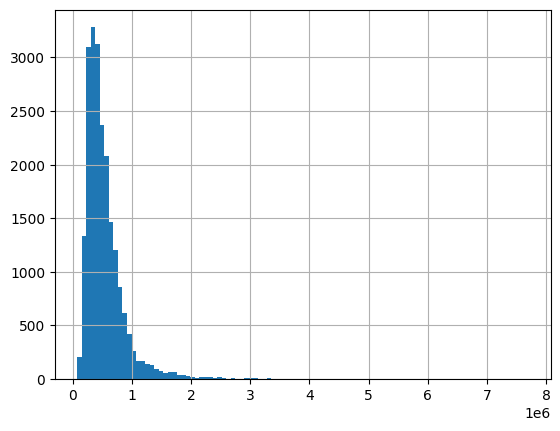

In [34]:
df.price.hist(bins=100)

Гістограма підтверджує здогад: більшість будинків коштують до ~1 млн, але є довгий "хвіст" дорогих об'єктів, який і зсуває середнє вправо відносно медіани.

### Розділяємо на "економ" і "VIP" сегменти

Щоб перевірити вплив цього хвоста, розділимо дані за порогом $1 000 000.

In [37]:
df_econom = df[df['price'] < 1000000]
df_vip = df[df['price'] >= 1000000]

print('economy:', len(df_econom), 'рядків')
print('vip:', len(df_vip), 'рядків')

economy: 20119 рядків
vip: 1492 рядків


<Axes: >

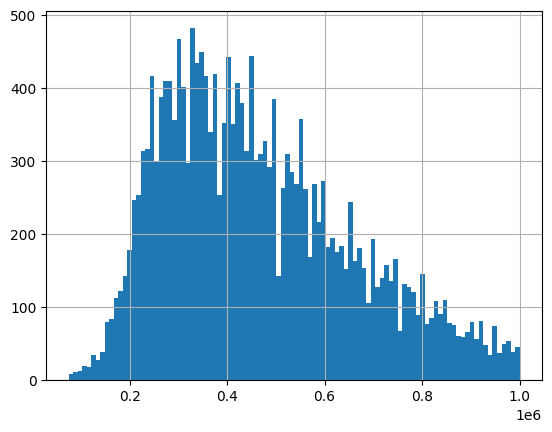

In [38]:
df_econom.price.hist(bins=100)

У сегменті "economy" розподіл виглядає значно симетричнішим. Порівняємо середнє й медіану саме тут.

In [40]:
df_econom.price.mean(), df_econom.price.median()

(np.float64(466975.9678910483), 433000.0)

Різниця між середнім (**≈466 987 $**) і медіаною (**433 000 $**) стала помітно меншою, ніж по всьому датасету — прибравши невелику кількість дуже дорогих об'єктів, ми прибрали й основне джерело скошеності.

<Axes: >

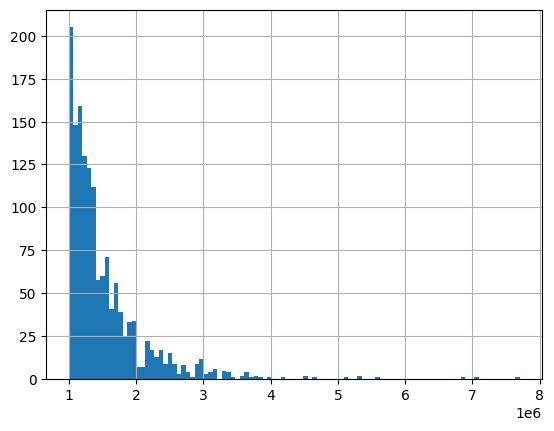

In [41]:
df_vip.price.hist(bins=100)

У "VIP"-сегменті об'єктів набагато менше, і розподіл усе одно залишається правоскошеним (є будинки за кілька мільйонів на тлі "типового" мільйона з невеликим хвостиком) — цілком очікувано для елітного житла.

## Мода, розмах і стандартне відхилення

Для дискретної величини (кількість спалень) має сенс подивитись саме на **моду** — найтиповіше значення.

In [42]:
df.bedrooms.mode()

,bedrooms
0,3


Найпоширеніше значення — **3 спальні**: типовий сімейний будинок у цьому наборі даних.

Мінімум, максимум і розмах (`max - min`) дають швидке уявлення про діапазон цін.

In [43]:
df.price.min()

75000.0

In [44]:
df.price.max() - df.price.min()

7625000.0

Розмах у **7 625 000 $** — величезний, але сам по собі він нічого не каже про типовий розкид: розмах визначається лише двома крайніми точками (найдешевшим і найдорожчим будинком) і дуже чутливий до викидів. Тому для оцінки типового розкиду краще підходить **стандартне відхилення**.

In [46]:
df.price.mean()

np.float64(540085.0265142751)

In [45]:
df.price.std()

367143.04925800796

Стандартне відхилення (**≈367 127 $**) порівнянне за порядком величини із самою середньою ціною (540 088 $) — це ще одна ознака великого розкиду й скошеності розподілу цін.

## Підсумок

**Головний висновок:** для скошених розподілів (як ціни на житло) середнє й стандартне відхилення можуть вводити в оману — варто завжди дивитись на медіану та гістограму, а не лише на одне число.

### Завдання для самостійної роботи

1. Порахуйте `describe()` для `sqft_living` окремо для `df_econom` і `df_vip`. Чим відрізняється розкид площі в цих двох сегментах?
2. Заповніть 2 пропуски в `sqft_above` через `sqft_living - sqft_basement` і перевірте, що після цього `isna().sum()` для цієї колонки дає 0.
3. Побудуйте `value_counts()` для колонки `condition` (стан будинку) — це номінальна чи порядкова шкала? Обґрунтуйте відповідь.
4. Порівняйте медіанну ціну будинків із `waterfront == 1` (біля води) і `waterfront == 0`.